In [1]:
import jax
jax.config.update("jax_enable_x64", True)  # Enable 64-bit precision
jax.config.update("jax_debug_nans", True)
jax.config.update("jax_platforms", "cpu")
import jax.numpy as jnp
import jax.random as random
from jax import lax

# import numpyro
# numpyro.set_host_device_count(4)
# import numpyro.distributions as dist
# from numpyro.infer import MCMC, NUTS, Predictive
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import orthax
import functools
import pandas as pd

from typing import Dict, Tuple, NamedTuple, Callable,  Any, Optional
from dataclasses import dataclass
from enum import Enum


def scatter_vector(theta, lambda_0=633e-9, n=1.33, radians=False):
    """
    theta - scatter angle
    lambda_0 - lsder wavelength in meters
    n - refractive index of water
    """
    if not radians:
        theta = jnp.radians(theta)
    return (4 * jnp.pi * n/lambda_0) * jnp.sin(theta / 2)

def diffusion_coef(r, k_B=1.38e-23, T=298.15, eta=0.00089):
    """
    r - particle radius
    k_b - Boltzmann constant (J/K)
    T - Temperature (K)
    eta - Viscosity of water at room temerature (Pa*s)
    """
    return k_B * T / (6 * jnp.pi * eta * r)

def normal_to_lognormal_params(mu, sigma):
    sigma_ln_sq = jnp.log(1 + (sigma / mu)**2)
    mu_ln = jnp.log(mu) - (sigma_ln_sq / 2)
    sigma_ln = jnp.sqrt(sigma_ln_sq)
    return (mu_ln, sigma_ln)

def prep_data(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s

    # observation data is g2(t) - 1
    g2_minus1_obs = d[:, 1:].T

    div = jax.vmap(lambda x: x/x[0])
    g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    # g1 = jnp.sqrt(jnp.maximum(g1_squared, 0)) # this line converts to g1

    g1 = jnp.where(
        jnp.greater_equal(g1_squared, 0),
        jnp.sqrt(g1_squared),
        -jnp.sqrt(-g1_squared)
    )

    # g1 = jnp.sign(g1_squared) * jnp.sqrt(jnp.abs(g1_squared))

    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    return q, t, g1

def prep_data_g2(datafile):
    df = pd.read_csv(datafile, delimiter='\t', header=None)
    df = df.iloc[1:] # remove strange first point
    d = jnp.array(df.to_numpy())

    t = d[:, 0]
    t *=  1e-3 # convert timestamps from ms to s

    # observation data is g2(t) - 1
    g2_minus1_obs = d[:, 1:].T

    div = jax.vmap(lambda x: x/x[0])
    g1_squared = div(g2_minus1_obs) # normalization by first term handles removing the beta term (roughly)

    # # g1 = jnp.sqrt(jnp.maximum(g1_squared, 0)) # this line converts to g1
    # g1 = jnp.where(
    #     jnp.greater_equal(g1_squared, 0),
    #     jnp.sqrt(g1_squared),
    #     -jnp.sqrt(-g1_squared)
    # )

    theta = jnp.arange(30., 151, 5) # angles known in advance - in degrees
    q = scatter_vector(theta)
    # return q, t, g2_minus1_obs
    return q, t, g1_squared

### models
SCALING_CONST = 2.45e-12


######### Normal model ##########

def get_g1(t, nk, a, c):
    b = a**2/2
    d = jnp.sqrt(2)
    s_pi = jnp.sqrt(jnp.pi)
    x = (-a + c*t)/d
    y = jnp.where(
        jnp.greater_equal(x, 5),
        1/(x*s_pi),
        jax.scipy.special.erfc(x)*jnp.exp(x**2)
    )
    e = (nk/2)*jnp.exp(-b)
    return e*y

# vectorize along time dimension
all_g1 = jax.vmap(
    get_g1,
    in_axes=(0, None, None, None)
)

def source3_1(t, q, amp, mu, sig):
    ################
    const = SCALING_CONST
    # const = 1.0
    ################
    nk = amp
    sig = sig*const
    mu = mu*const
    a = mu/sig
    c = q**2*sig

    g = all_g1(t, nk, a, c)
    return g

by_Xs1 = jax.vmap(
    source3_1,
    in_axes=(None, None, 0, 0, 0)
)

source_matrix1 = jax.vmap(
    by_Xs1,
    in_axes=(None, 0, None, None, None)
)

def g1_matrix(q, t, amp, mu, sig):
    full = source_matrix1(t, q, amp, mu, sig)
    full = jnp.sum(full, axis=1)
    return full

@jax.jit
def g2_minus1_matrix(q, t, amp, mu, sig, beta):
    g1 = g1_matrix(q, t, amp, mu, sig)
    g2_minus1 = beta * g1**2
    return g2_minus1


import jax
import jax.numpy as jnp
from jax.scipy.stats import norm, dirichlet, beta as beta_dist, gamma
from jax import random
from collections import namedtuple
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import trange
from jax.scipy.special import gammaln, logsumexp


# ========== RJMCMC FOR DLS ==========

# Define state for DLS model
DLSState = namedtuple("DLSState", ["k", "amp", "mu", "sig", "beta", "sigma_noise", "log_posterior"])

# Helper functions
@jax.jit
def invgamma_logpdf(x, a, b):
    """Log PDF of Inverse-Gamma distribution."""
    x = jnp.maximum(x, 1e-10)
    return a * jnp.log(b) - gammaln(a) - (a + 1) * jnp.log(x) - b / x

@jax.jit
def sample_inverse_gamma(key, a, b):
    """Sample from Inverse-Gamma(a, b)."""
    gamma_sample = random.gamma(key, a)
    return b / gamma_sample

@jax.jit
def truncated_normal_sample(key, mean, std, lower, upper):
    """Sample from truncated normal distribution."""
    # Use inverse CDF method
    u = random.uniform(key)
    a_std = (lower - mean) / std
    b_std = (upper - mean) / std
    
    cdf_a = norm.cdf(a_std)
    cdf_b = norm.cdf(b_std)
    
    truncated_u = cdf_a + u * (cdf_b - cdf_a)
    return mean + std * norm.ppf(truncated_u)

@jax.jit
def log_likelihood_dls(data, q_values, t_values, state):
    """Calculate log-likelihood for DLS g2 data."""
    # Get active parameters
    active_amp = state.amp + jnp.finfo(state.amp.dtype).eps
    active_mu = state.mu + jnp.finfo(state.mu.dtype).eps
    active_sig = state.sig + jnp.finfo(state.sig.dtype).eps

    # Ensure amplitudes sum to 1
    active_amp = active_amp / jnp.sum(active_amp)
    
    # Get model predictions
    g2_pred = g2_minus1_matrix(q_values, t_values, active_amp, active_mu, active_sig, state.beta)
    
    # Gaussian noise model
    residuals = data - g2_pred
    n_points = data.size
    
    log_lik = -0.5 * jnp.sum(residuals**2) / state.sigma_noise**2
    log_lik -= 0.5 * n_points * jnp.log(2 * jnp.pi * state.sigma_noise**2)
    
    return log_lik

@functools.partial(jax.jit, static_argnums=(1,))
def log_prior_dls(state, k_max, prior_params):
    """Calculate log prior for DLS parameters."""
    k = state.k
    
    # Create boolean mask for active components
    mask = jnp.arange(k_max) < k
    one_hot_mask = jnp.zeros(k_max, dtype=bool).at[k-1].set(True)
    
    # Work with full arrays up to k_max
    amp_full = state.amp + jnp.finfo(state.amp.dtype).eps
    mu_full = state.mu + jnp.finfo(state.mu.dtype).eps
    sig_full = state.sig + jnp.finfo(state.sig.dtype).eps
    
    # Prior on k - uniform
    log_p_k = -jnp.log(k_max)
    
    # Prior on amplitudes - Dirichlet (they sum to 1)
    # Only sum the active amplitudes
    active_amp_sum = jnp.sum(jnp.where(mask, amp_full, 0.0))
    amp_full_norm = amp_full / active_amp_sum

    dirichlets = jnp.stack([dirichlet.logpdf(amp_full_norm[:kk], alpha=jnp.ones(kk) * prior_params['amp_alpha']) for kk in range(1, k_max+1)])
    log_p_amp = jnp.sum(jnp.where(one_hot_mask.astype(bool), 
            dirichlets,
            0.0))

    # Manual Dirichlet logpdf calculation with masking
    # log_p_amp = jnp.sum(jnp.where(mask, 
    #                              (prior_params['amp_alpha'] - 1) * jnp.log(amp_full_norm),
    #                              0.0))
    # # Add normalization terms for Dirichlet
    # log_p_amp += jnp.sum(jnp.where(mask, jax.scipy.special.gammaln(prior_params['amp_alpha']), 0.0))
    # log_p_amp -= jax.scipy.special.gammaln(k * prior_params['amp_alpha'])
    
    # Prior on mu - log-normal truncated to [0.1, 2]
    log_mu_full = jnp.log(mu_full)
    mu_logpdf = norm.logpdf(log_mu_full, prior_params['log_mu_mean'], prior_params['log_mu_std'])
    log_p_mu = jnp.sum(jnp.where(mask, mu_logpdf, 0.0))
    
    # Add truncation penalty (only for active components)
    truncation_penalty = jnp.log((mu_full >= 0.1) & (mu_full <= 2.0))
    log_p_mu += jnp.sum(jnp.where(mask, truncation_penalty, 0.0))
    
    # Prior on sig - Beta scaled to [0.065, 0.15]
    sig_scaled = (sig_full - 0.065) / (0.15 - 0.065)
    sig_logpdf = beta_dist.logpdf(sig_scaled, a=prior_params['sig_alpha'], b=prior_params['sig_beta'])
    log_p_sig = jnp.sum(jnp.where(mask, sig_logpdf, 0.0))
    log_p_sig -= k * jnp.log(0.15 - 0.065)  # Jacobian for scaling
    
    # Prior on beta - Beta distribution on [0, 1]
    log_p_beta = beta_dist.logpdf(state.beta, a=prior_params['beta_alpha'], b=prior_params['beta_beta'])
    
    # Prior on noise - Inverse Gamma
    log_p_sigma = invgamma_logpdf(state.sigma_noise**2, prior_params['noise_a'], prior_params['noise_b'])
    log_p_sigma += jnp.log(2 * state.sigma_noise)  # Jacobian for sigma^2 -> sigma
    
    return log_p_k + log_p_amp + log_p_mu + log_p_sig + log_p_beta + log_p_sigma

# def log_prior_dls_o(state, k_max, prior_params):
#     """Calculate log prior for DLS parameters."""
#     k = state.k
#     active_amp = state.amp[:k]
#     active_mu = state.mu[:k]
#     active_sig = state.sig[:k]
    
#     # Prior on k - uniform
#     log_p_k = -jnp.log(k_max)
    
#     # Prior on amplitudes - Dirichlet (they sum to 1)
#     active_amp_norm = active_amp / jnp.sum(active_amp)
#     log_p_amp = dirichlet.logpdf(active_amp_norm, alpha=jnp.ones(k) * prior_params['amp_alpha'])
    
#     # Prior on mu - log-normal truncated to [0.1, 2]
#     log_mu = jnp.log(active_mu)
#     log_p_mu = jnp.sum(norm.logpdf(log_mu, prior_params['log_mu_mean'], prior_params['log_mu_std']))
#     # Add truncation penalty
#     log_p_mu += jnp.sum(jnp.log((active_mu >= 0.1) & (active_mu <= 2.0)))
    
#     # Prior on sig - Beta scaled to [0.065, 0.15]
#     sig_scaled = (active_sig - 0.065) / (0.15 - 0.065)
#     log_p_sig = jnp.sum(beta_dist.logpdf(sig_scaled, a=prior_params['sig_alpha'], b=prior_params['sig_beta']))
#     log_p_sig -= k * jnp.log(0.15 - 0.065)  # Jacobian for scaling
    
#     # Prior on beta - Beta distribution on [0, 1]
#     log_p_beta = beta_dist.logpdf(state.beta, a=prior_params['beta_alpha'], b=prior_params['beta_beta'])
    
#     # Prior on noise - Inverse Gamma
#     log_p_sigma = invgamma_logpdf(state.sigma_noise**2, prior_params['noise_a'], prior_params['noise_b'])
#     log_p_sigma += jnp.log(2 * state.sigma_noise)  # Jacobian for sigma^2 -> sigma
    
#     return log_p_k + log_p_amp + log_p_mu + log_p_sig + log_p_beta + log_p_sigma

# def calculate_log_posterior_dls(data, q_values, t_values, state, k_max, prior_params):
#     """Calculate full log posterior."""
#     # Check validity
#     if state.k < 1 or state.k > k_max:
#         return -jnp.inf
    
#     active_mu = state.mu[:state.k]
#     active_sig = state.sig[:state.k]
#     active_amp = state.amp[:state.k]
    
#     # Check parameter bounds
#     if (jnp.any(active_mu < 0.1) or jnp.any(active_mu > 2.0) or
#         jnp.any(active_sig < 0.065) or jnp.any(active_sig > 0.15) or
#         jnp.any(active_amp <= 0) or state.beta <= 0 or state.beta >= 1 or
#         state.sigma_noise <= 0):
#         return -jnp.inf
    
#     log_prior = log_prior_dls(state, k_max, prior_params)
#     log_lik = log_likelihood_dls(data, q_values, t_values, state)
    
#     return log_prior + log_lik
@functools.partial(jax.jit, static_argnums=(4))
def calculate_log_posterior_dls_valid(data, q_values, t_values, state, k_max, prior_params):
    """Calculate full log posterior."""
    k = state.k

    # Create boolean mask for active components
    mask = jnp.arange(k_max) < k
    one_hot_mask = jnp.zeros(k_max, dtype=bool).at[k-1].set(True)

    # out_of_bounds_k = jnp.array([(
    #     jnp.any(state.mu[:kk] < 0.1) or jnp.any(state.mu[:kk] > 2.0) or
    #     jnp.any(state.sig[:kk] < 0.065) or jnp.any(state.sig[:kk] > 0.15) or
    #     jnp.any(state.amp[:kk] <= 0) or state.beta <= 0 or state.beta >= 1 or
    #     state.sigma_noise <= 0
    # ) for kk in range(1, k_max + 1)])

    out_of_bounds_k = (
        (state.mu < 0.1) |
        (state.mu > 2.0) |
        (state.sig < 0.065) |
        (state.sig > 0.15) |
        (state.amp <= 0)
    )
    k_param_bounded = jnp.any(mask & out_of_bounds_k)
        # state.beta <= 0 |
        # state.beta >= 1 |
        # state.sigma_noise <= 0

    out_of_bounds = k_param_bounded | (state.beta <= 0) | (state.beta >= 1) | (state.sigma_noise <= 0)

        
    log_prior = log_prior_dls(state, k_max, prior_params)
    log_lik = log_likelihood_dls(data, q_values, t_values, state)
    inbounds_result = log_prior + log_lik
    return jnp.where(
        out_of_bounds,
        -jnp.inf,
        inbounds_result
    )

@functools.partial(jax.jit, static_argnums=(4))
def calculate_log_posterior_dls(data, q_values, t_values, state, k_max, prior_params):
    """Calculate full log posterior."""
    k = state.k
    return jnp.where(
        (state.k < 1) | (state.k > k_max),
        -jnp.inf,
        calculate_log_posterior_dls_valid(data, q_values, t_values, state, k_max, prior_params)
    )

# RJMCMC Moves

def birth_move_dls(key, data, q_values, t_values, k_max, prior_params, current_state):
    """Birth move: add a new component."""
    k = current_state.k
    
    if k >= k_max:
        return current_state
    
    key, mu_key, sig_key, amp_key, accept_key = random.split(key, 5)
    
    # Sample new component parameters
    # mu: log-normal truncated to [0.1, 2]
    log_mu_new = random.normal(mu_key) * prior_params['log_mu_std'] + prior_params['log_mu_mean']
    mu_new = jnp.clip(jnp.exp(log_mu_new), 0.1, 2.0)
    
    # sig: Beta scaled to [0.065, 0.15]
    sig_beta = random.beta(sig_key, prior_params['sig_alpha'], prior_params['sig_beta'])
    sig_new = 0.065 + sig_beta * (0.15 - 0.065)
    
    # Weight split using Beta(1, k)
    u = random.beta(amp_key, 1, k)
    
    # Current amplitudes
    old_amp = current_state.amp[:k]
    old_amp_norm = old_amp / jnp.sum(old_amp)
    
    # Split amplitudes
    new_component_amp = u
    existing_amp = old_amp_norm * (1 - u)
    all_amp = jnp.append(existing_amp, new_component_amp)
    
    # Combine all parameters
    all_mu = jnp.append(current_state.mu[:k], mu_new)
    all_sig = jnp.append(current_state.sig[:k], sig_new)
    
    # Sort by mu for identifiability
    sort_idx = jnp.argsort(all_mu)
    
    # Build proposed state
    prop_amp = jnp.zeros(k_max).at[:k+1].set(all_amp[sort_idx])
    prop_mu = jnp.zeros(k_max).at[:k+1].set(all_mu[sort_idx])
    prop_sig = jnp.zeros(k_max).at[:k+1].set(all_sig[sort_idx])
    
    proposed_state = DLSState(
        k=k+1,
        amp=prop_amp,
        mu=prop_mu,
        sig=prop_sig,
        beta=current_state.beta,
        sigma_noise=current_state.sigma_noise,
        log_posterior=0
    )
    
    # Calculate acceptance probability
    log_post_proposed = calculate_log_posterior_dls(data, q_values, t_values, proposed_state, k_max, prior_params)
    
    # Dimension matching and Jacobian
    log_dim_match = jnp.log(1/(k+1))  # Probability of selecting this component in reverse death
    log_jacobian = k * jnp.log(1 - u)  # Jacobian for weight transformation
    log_proposal_u = (k - 1) * jnp.log(1 - u) - jnp.log(k)  # Beta(1, k) density
    
    log_alpha = log_post_proposed - current_state.log_posterior + log_dim_match + log_jacobian - log_proposal_u
    
    if jnp.log(random.uniform(accept_key)) < log_alpha:
        return proposed_state._replace(log_posterior=log_post_proposed)
    else:
        return current_state

def death_move_dls(key, data, q_values, t_values, k_max, prior_params, current_state):
    """Death move: remove a component."""
    k = current_state.k
    
    if k <= 1:
        return current_state
    
    key, kill_key, accept_key = random.split(key, 3)
    
    # Choose component to kill
    j = random.randint(kill_key, (), 0, k)
    
    # Get current parameters
    current_amp = current_state.amp[:k]
    current_amp_norm = current_amp / jnp.sum(current_amp)
    current_mu = current_state.mu[:k]
    current_sig = current_state.sig[:k]
    
    # Calculate u for reverse birth move
    u = current_amp_norm[j]
    
    # Remove component
    keep_idx = jnp.arange(k) != j
    new_amp = current_amp_norm[keep_idx]
    new_amp = new_amp / jnp.sum(new_amp)  # Renormalize
    new_mu = current_mu[keep_idx]
    new_sig = current_sig[keep_idx]
    
    # Build proposed state
    prop_amp = jnp.zeros(k_max).at[:k-1].set(new_amp)
    prop_mu = jnp.zeros(k_max).at[:k-1].set(new_mu)
    prop_sig = jnp.zeros(k_max).at[:k-1].set(new_sig)
    
    proposed_state = DLSState(
        k=k-1,
        amp=prop_amp,
        mu=prop_mu,
        sig=prop_sig,
        beta=current_state.beta,
        sigma_noise=current_state.sigma_noise,
        log_posterior=0
    )
    
    # Calculate acceptance probability
    log_post_proposed = calculate_log_posterior_dls(data, q_values, t_values, proposed_state, k_max, prior_params)
    
    # Reverse of birth move terms
    log_dim_match = -jnp.log(1/k)
    log_jacobian = -(k-1) * jnp.log(1 - u)
    log_proposal_u = (k - 2) * jnp.log(1 - u) - jnp.log(k - 1)
    
    log_alpha = log_post_proposed - current_state.log_posterior + log_dim_match + log_jacobian + log_proposal_u
    
    if jnp.log(random.uniform(accept_key)) < log_alpha:
        return proposed_state._replace(log_posterior=log_post_proposed)
    else:
        return current_state

def within_model_update_dls(key, data, q_values, t_values, k_max, prior_params, current_state):
    """Update parameters within current model."""
    k = current_state.k
    
    key, amp_key, mu_key, sig_key, beta_key, noise_key, accept_key = random.split(key, 7)
    
    # Get active parameters
    active_amp = current_state.amp[:k]
    active_mu = current_state.mu[:k]
    active_sig = current_state.sig[:k]
    
    # Propose new parameters
    # Amplitudes: Dirichlet centered at current
    concentration = 50.0
    prop_amp = random.dirichlet(amp_key, active_amp * concentration / jnp.sum(active_amp))
    
    # Mu: log-normal random walk, clipped to bounds
    log_mu = jnp.log(active_mu)
    prop_log_mu = log_mu + random.normal(mu_key, shape=(k,)) * 0.1
    prop_mu = jnp.clip(jnp.exp(prop_log_mu), 0.1, 2.0)
    
    # Sig: random walk on logit scale to maintain bounds
    sig_logit = jnp.log((active_sig - 0.065) / (0.15 - active_sig))
    prop_sig_logit = sig_logit + random.normal(sig_key, shape=(k,)) * 0.2
    prop_sig = 0.065 + (0.15 - 0.065) / (1 + jnp.exp(-prop_sig_logit))
    
    # Beta: random walk on logit scale
    beta_logit = jnp.log(current_state.beta / (1 - current_state.beta))
    prop_beta_logit = beta_logit + random.normal(beta_key) * 0.1
    prop_beta = 1 / (1 + jnp.exp(-prop_beta_logit))
    
    # Noise: log-normal random walk
    log_sigma = jnp.log(current_state.sigma_noise)
    prop_log_sigma = log_sigma + random.normal(noise_key) * 0.1
    prop_sigma_noise = jnp.exp(prop_log_sigma)
    
    # Sort by mu for identifiability
    sort_idx = jnp.argsort(prop_mu)
    prop_amp = prop_amp[sort_idx]
    prop_mu = prop_mu[sort_idx]
    prop_sig = prop_sig[sort_idx]
    
    # Build proposed state
    new_amp = jnp.zeros(k_max).at[:k].set(prop_amp)
    new_mu = jnp.zeros(k_max).at[:k].set(prop_mu)
    new_sig = jnp.zeros(k_max).at[:k].set(prop_sig)
    
    proposed_state = DLSState(
        k=k,
        amp=new_amp,
        mu=new_mu,
        sig=new_sig,
        beta=prop_beta,
        sigma_noise=prop_sigma_noise,
        log_posterior=0
    )
    
    # Calculate acceptance probability
    log_post_proposed = calculate_log_posterior_dls(data, q_values, t_values, proposed_state, k_max, prior_params)
    
    # Proposals are approximately symmetric
    log_alpha = log_post_proposed - current_state.log_posterior
    
    if jnp.log(random.uniform(accept_key)) < log_alpha:
        return proposed_state._replace(log_posterior=log_post_proposed)
    else:
        return current_state

def rjmcmc_sampler_dls(key, n_iter, initial_state, data, q_values, t_values, 
                       k_max, prior_params, verbose=True):
    """Main RJMCMC sampler for DLS data."""
    # Calculate initial log posterior
    current_state = initial_state._replace(
        log_posterior=calculate_log_posterior_dls(data, q_values, t_values, 
                                                  initial_state, k_max, prior_params)
    )
    
    # Storage
    samples = {
        'k': [],
        'beta': [],
        'sigma_noise': [],
        'log_posterior': []
    }
    n_accept = {'birth': 0, 'death': 0, 'update': 0}
    n_propose = {'birth': 0, 'death': 0, 'update': 0}
    
    # Also store some full states for later analysis
    state_snapshots = []
    snapshot_interval = n_iter // 20  # Save 20 snapshots
    
    iterator = trange(n_iter, desc="RJMCMC-DLS") if verbose else range(n_iter)
    
    for i in iterator:
        key, step_key, move_key = random.split(key, 3)
        
        # Choose move type
        move_probs = jnp.array([0.5, 0.25, 0.25])  # update, birth, death
        move_type = random.choice(move_key, 3, p=move_probs)
        
        old_state = current_state
        
        if move_type == 0:  # Within-model update
            current_state = within_model_update_dls(step_key, data, q_values, t_values, 
                                                    k_max, prior_params, current_state)
            n_propose['update'] += 1
            if current_state.log_posterior != old_state.log_posterior:
                n_accept['update'] += 1
                
        elif move_type == 1:  # Birth
            current_state = birth_move_dls(step_key, data, q_values, t_values, 
                                           k_max, prior_params, current_state)
            n_propose['birth'] += 1
            if current_state.k != old_state.k:
                n_accept['birth'] += 1
                
        else:  # Death
            current_state = death_move_dls(step_key, data, q_values, t_values, 
                                           k_max, prior_params, current_state)
            n_propose['death'] += 1
            if current_state.k != old_state.k:
                n_accept['death'] += 1
        
        # Store samples
        samples['k'].append(current_state.k)
        samples['beta'].append(current_state.beta)
        samples['sigma_noise'].append(current_state.sigma_noise)
        samples['log_posterior'].append(current_state.log_posterior)
        
        # Store snapshots
        if i % snapshot_interval == 0:
            state_snapshots.append(current_state)
        
        # Update progress bar
        if verbose and (i + 1) % 50 == 0:
            acc_rates = {
                move: n_accept[move] / max(n_propose[move], 1) 
                for move in ['birth', 'death', 'update']
            }
            iterator.set_postfix({
                'k': current_state.k,
                'beta': f"{current_state.beta:.3f}",
                'acc_b': f"{acc_rates['birth']:.2f}",
                'acc_d': f"{acc_rates['death']:.2f}",
                'acc_u': f"{acc_rates['update']:.2f}"
            })
    
    # Convert to arrays
    for key in samples:
        samples[key] = jnp.array(samples[key])
    
    # Print final acceptance rates
    if verbose:
        print("\nFinal acceptance rates:")
        for move in ['birth', 'death', 'update']:
            rate = n_accept[move] / max(n_propose[move], 1)
            print(f"  {move:8s}: {rate:.3f} ({n_accept[move]}/{n_propose[move]})")
    
    samples['state_snapshots'] = state_snapshots
    samples['acceptance_rates'] = {
        move: n_accept[move] / max(n_propose[move], 1) 
        for move in ['birth', 'death', 'update']
    }
    
    return samples

# ========== UTILITIES FOR ANALYSIS ==========

def plot_dls_results(samples, data, q_values, t_values, burn_in=1000, true_params=None):
    """Plot comprehensive results from DLS RJMCMC."""
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    # Remove burn-in
    k_samples = samples['k'][burn_in:]
    beta_samples = samples['beta'][burn_in:]
    sigma_samples = samples['sigma_noise'][burn_in:]
    logpost_samples = samples['log_posterior'][burn_in:]
    
    # 1. Trace plot of k
    axes[0, 0].plot(k_samples)
    if true_params and 'k' in true_params:
        axes[0, 0].axhline(true_params['k'], color='red', linestyle='--', label=f'True k={true_params["k"]}')
    axes[0, 0].set_title("Trace: Number of Components (k)")
    axes[0, 0].set_xlabel("Iteration")
    axes[0, 0].set_ylabel("k")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Posterior of k
    unique_k, counts = jnp.unique(k_samples, return_counts=True)
    posterior_probs = counts / len(k_samples)
    axes[0, 1].bar(unique_k, posterior_probs, alpha=0.7)
    if true_params and 'k' in true_params:
        axes[0, 1].axvline(true_params['k'], color='red', linestyle='--')
    axes[0, 1].set_title("Posterior Distribution of k")
    axes[0, 1].set_xlabel("Number of Components")
    axes[0, 1].set_ylabel("Probability")
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Log posterior trace
    axes[0, 2].plot(logpost_samples)
    axes[0, 2].set_title("Trace: Log Posterior")
    axes[0, 2].set_xlabel("Iteration")
    axes[0, 2].set_ylabel("Log Posterior")
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Beta trace
    axes[1, 0].plot(beta_samples)
    if true_params and 'beta' in true_params:
        axes[1, 0].axhline(true_params['beta'], color='red', linestyle='--')
    axes[1, 0].set_title("Trace: Beta (Coherence)")
    axes[1, 0].set_xlabel("Iteration")
    axes[1, 0].set_ylabel("Beta")
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Beta histogram
    axes[1, 1].hist(beta_samples, bins=30, density=True, alpha=0.7)
    if true_params and 'beta' in true_params:
        axes[1, 1].axvline(true_params['beta'], color='red', linestyle='--')
    axes[1, 1].set_title("Posterior: Beta")
    axes[1, 1].set_xlabel("Beta")
    axes[1, 1].set_ylabel("Density")
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Noise trace
    axes[1, 2].plot(sigma_samples)
    axes[1, 2].set_title("Trace: Noise (σ)")
    axes[1, 2].set_xlabel("Iteration")
    axes[1, 2].set_ylabel("Noise σ")
    axes[1, 2].grid(True, alpha=0.3)
    
    # 7. Fit quality - show data vs model for first q value
    q_idx = 0
    axes[2, 0].scatter(t_values, data[q_idx, :], alpha=0.5, s=10, label='Data')
    
    # Get posterior mean model
    posterior_mode_k = unique_k[jnp.argmax(counts)]
    
    # Find a state with modal k from snapshots
    for state in samples['state_snapshots'][-10:]:  # Check last 10 snapshots
        if state.k == posterior_mode_k:
            active_amp = state.amp[:state.k]
            active_mu = state.mu[:state.k]
            active_sig = state.sig[:state.k]
            
            model_pred = g2_minus1_matrix(q_values, t_values, active_amp, active_mu, active_sig, state.beta)
            axes[2, 0].plot(t_values, model_pred[q_idx, :], 'r-', alpha=0.8, label=f'Model (k={state.k})')
            break
    
    axes[2, 0].set_xscale('log')
    axes[2, 0].set_title(f"Fit Quality (q={q_values[q_idx]:.3f})")
    axes[2, 0].set_xlabel("Time")
    axes[2, 0].set_ylabel("g2(t) - 1")
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    
    # 8. Residuals for all q values
    if len(samples['state_snapshots']) > 0:
        state = samples['state_snapshots'][-1]  # Use last state
        active_amp = state.amp[:state.k]
        active_mu = state.mu[:state.k]
        active_sig = state.sig[:state.k]
        
        model_pred = g2_minus1_matrix(q_values, t_values, active_amp, active_mu, active_sig, state.beta)
        residuals = data - model_pred
        
        im = axes[2, 1].imshow(residuals, aspect='auto', cmap='RdBu_r', vmin=-3*state.sigma_noise, vmax=3*state.sigma_noise)
        axes[2, 1].set_title("Residuals Map")
        axes[2, 1].set_xlabel("Time Index")
        axes[2, 1].set_ylabel("q Index")
        plt.colorbar(im, ax=axes[2, 1])
    
    # 9. Parameter summary text
    axes[2, 2].axis('off')
    summary_text = "Posterior Summary\n" + "="*20 + "\n\n"
    summary_text += f"k mode: {posterior_mode_k}\n"
    summary_text += f"k mean: {jnp.mean(k_samples):.2f}\n\n"
    
    for k_val, prob in sorted(zip(unique_k, posterior_probs), key=lambda x: -x[1])[:5]:
        summary_text += f"P(k={k_val}) = {prob:.3f}\n"
    
    summary_text += f"\nβ mean: {jnp.mean(beta_samples):.3f}\n"
    summary_text += f"β std: {jnp.std(beta_samples):.3f}\n"
    summary_text += f"\nσ mean: {jnp.mean(sigma_samples):.4f}\n"
    summary_text += f"σ std: {jnp.std(sigma_samples):.4f}\n"
    
    axes[2, 2].text(0.1, 0.9, summary_text, transform=axes[2, 2].transAxes,
                    fontsize=10, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    return fig

ERROR:2025-09-16 01:49:16,136:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/gfertt/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 100; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


Data shape: (25, 165)
True parameters: k=2, beta=1.000
True mu: [1.4 0.3]
True sig: [0.2  0.09]

Running RJMCMC for 300 iterations...


RJMCMC-DLS:   0%|          | 0/300 [00:00<?, ?it/s]


Final acceptance rates:
  birth   : 0.114 (9/79)
  death   : 0.070 (5/71)
  update  : 0.147 (22/150)


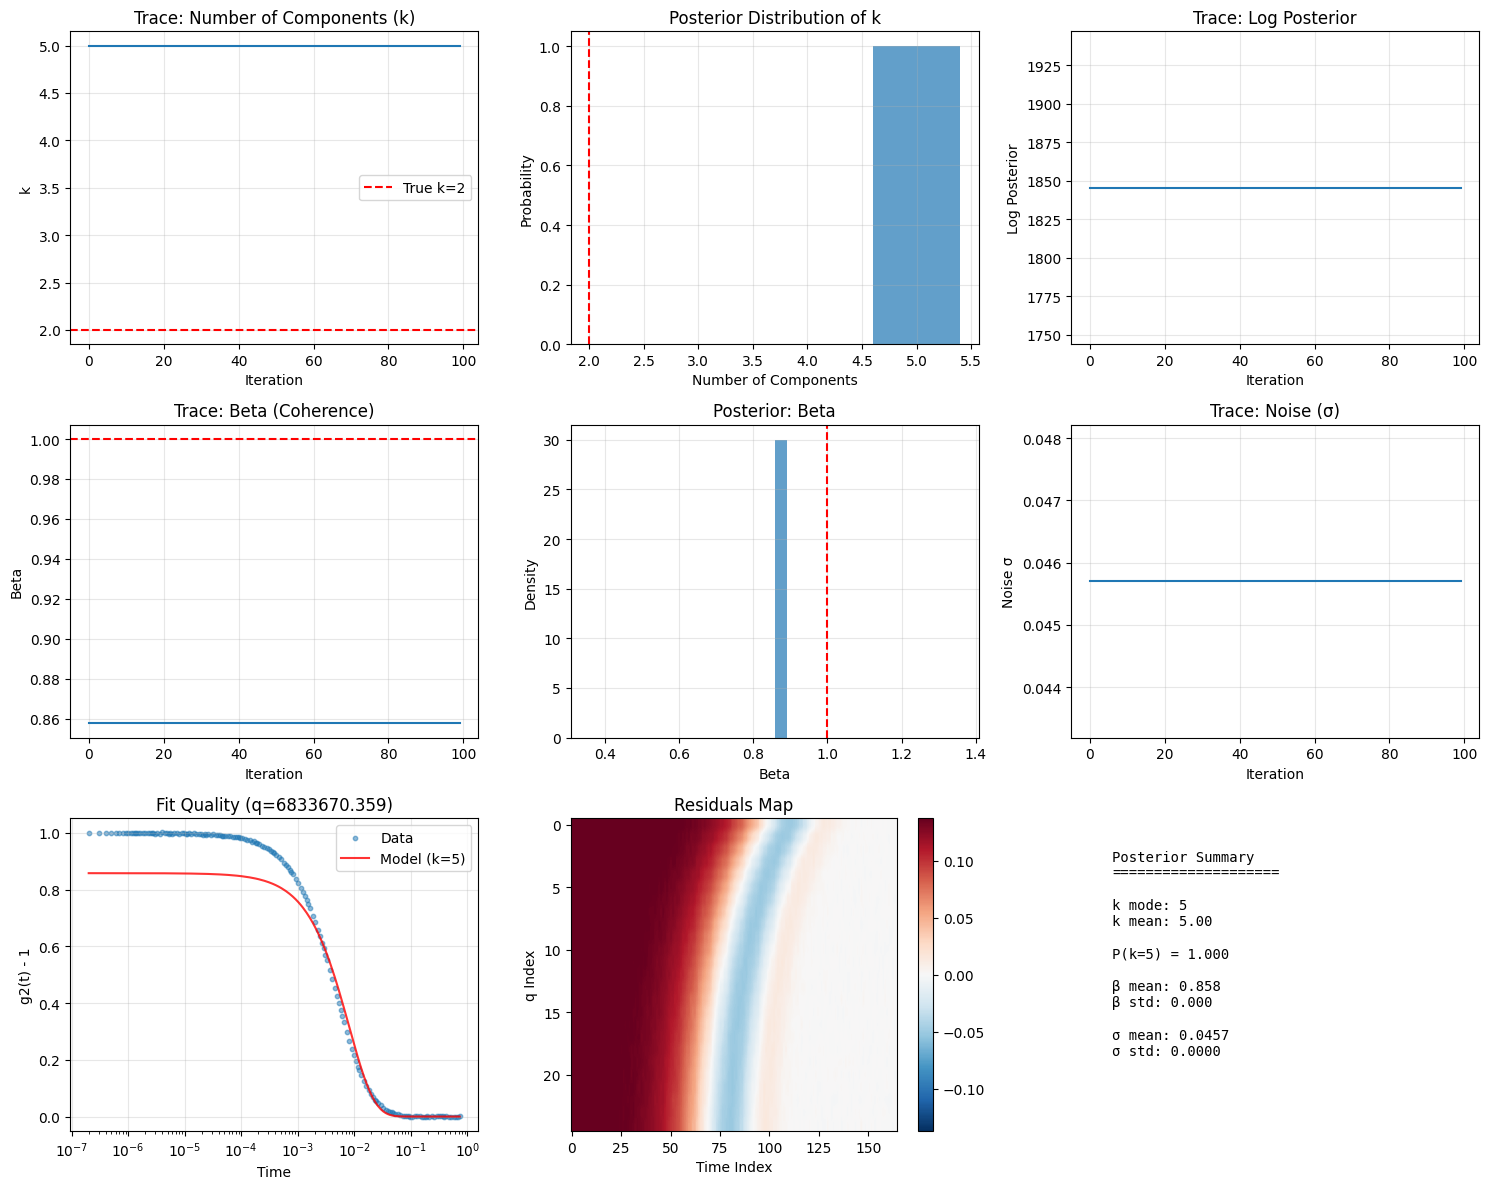


POSTERIOR SUMMARY

Posterior probabilities for k:
  P(k=5 | data) = 1.0000  

Beta posterior: 0.858 ± 0.000
True beta: 1.000

Noise posterior: 0.0457 ± 0.0000
True noise: 0.0010


In [2]:
if __name__ == "__main__":
    # Setup
    key = random.PRNGKey(1337)
    

## generate data 
    key, model_key, data_key = jax.random.split(key, 3)

    q_vals, t_vals, _ = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_100nm.csv")
    # True parameters for generating synthetic data
    true_params = {
        'k': 2,
        'beta': 1.0,
        'amp': jnp.array([0.5, 0.5]),
        'mu': jnp.array([1.4, 0.3]),
        'sig': jnp.array([0.2, 0.09]),
        'sigma': 0.001
        # 'sigma': 0.0
    }
    true_g2 = g2_minus1_matrix(
        q_vals, t_vals,
        true_params['amp'], true_params['mu'], true_params['sig'], true_params['beta']
    )

    true_k = 2
    data = true_g2 + true_params['sigma'] * jax.random.normal(data_key, shape=true_g2.shape)

    
    print(f"Data shape: {data.shape}")
    print(f"True parameters: k={true_params['k']}, beta={true_params['beta']:.3f}")
    print(f"True mu: {true_params['mu']}")
    print(f"True sig: {true_params['sig']}")
    
    # Set priors
    k_max = 5
    prior_params = {
        'amp_alpha': 1.0,           # Dirichlet concentration
        'log_mu_mean': jnp.log(0.5),  # Log-normal prior for mu
        'log_mu_std': 0.5,
        'sig_alpha': 2.0,           # Beta parameters for sig
        'sig_beta': 2.0,
        'beta_alpha': 5.0,          # Beta prior for coherence factor
        'beta_beta': 2.0,           # Favors higher beta values
        'noise_a': 2.0,             # Inverse gamma for noise
        'noise_b': 0.0001,
    }
    
    # Initialize
    initial_k = 1
    initial_amp = jnp.zeros(k_max).at[:initial_k].set(1.0)
    initial_mu = jnp.zeros(k_max).at[:initial_k].set(0.7)
    initial_sig = jnp.zeros(k_max).at[:initial_k].set(0.09)
    initial_beta = 0.7
    initial_sigma = 0.01
    
    initial_state = DLSState(
        k=initial_k,
        amp=initial_amp,
        mu=initial_mu,
        sig=initial_sig,
        beta=initial_beta,
        sigma_noise=initial_sigma,
        log_posterior=0.0
    )
    
    # Run RJMCMC
    n_iter = 300
    burn_in = 200
    
    print(f"\nRunning RJMCMC for {n_iter} iterations...")
    key, sampler_key = random.split(key)
    samples = rjmcmc_sampler_dls(
        key=sampler_key,
        n_iter=n_iter,
        initial_state=initial_state,
        data=data,
        q_values=q_vals,
        t_values=t_vals,
        k_max=k_max,
        prior_params=prior_params,
        verbose=True
    )
    
    # Plot results
    fig = plot_dls_results(samples, data, q_vals, t_vals, burn_in=burn_in, true_params=true_params)
    plt.show()
    
    # Print summary
    k_samples = samples['k'][burn_in:]
    unique_k, counts = jnp.unique(k_samples, return_counts=True)
    posterior_probs = counts / len(k_samples)
    
    print("\n" + "="*50)
    print("POSTERIOR SUMMARY")
    print("="*50)
    print(f"\nPosterior probabilities for k:")
    for k_val, prob in sorted(zip(unique_k, posterior_probs), key=lambda x: -x[1]):
        stars = "*" if k_val == true_params['k'] else " "
        print(f"  P(k={k_val} | data) = {prob:.4f} {stars}")
    
    print(f"\nBeta posterior: {jnp.mean(samples['beta'][burn_in:]):.3f} ± {jnp.std(samples['beta'][burn_in:]):.3f}")
    print(f"True beta: {true_params['beta']:.3f}")
    
    print(f"\nNoise posterior: {jnp.mean(samples['sigma_noise'][burn_in:]):.4f} ± {jnp.std(samples['sigma_noise'][burn_in:]):.4f}")
    print(f"True noise: {true_params['sigma']:.4f}")


In [4]:
# ==============================================================================
# ===== CODE IMPLEMENTING THE METHOD FROM BOUALEM ET AL. (2014) PAPER ==========
# ==============================================================================

from jax.scipy.stats import beta as beta_pdf

# --- 1. New Prior Distributions Informed by the Paper ---

# The paper uses Uniform priors for mu and a Jeffreys-like prior for sigma.
# A Jeffreys prior p(x) ∝ 1/x is equivalent to a Uniform prior on log(x).
# We'll also keep the `beta` parameter from your model, as it's required.
prior_params_paper = {
    'amp_alpha': 1.0,          # Dirichlet concentration for weights (remains a good choice)
    
    # Uniform prior for mu on [mu_min, mu_max]
    'mu_min': 0.1,             
    'mu_max': 2.0,
    
    # Jeffreys/Log-Uniform prior for sig on [sig_min, sig_max]
    'sig_min': 0.01,
    'sig_max': 0.5,
    
    'beta_alpha': 5.0,         # Beta prior for coherence factor (kept from original code)
    'beta_beta': 2.0,
    
    # Jeffreys prior for noise variance: p(σ_n^2) ∝ 1/σ_n^2
    # This is approximated with a vague Inverse Gamma prior.
    'noise_a': 0.001,
    'noise_b': 0.001,
}

# def log_prior_dls_paper_o(state, k_max, prior_params):
#     """Calculate log prior based on the paper's choices."""
#     k = state.k
#     active_amp = state.amp[:k]
#     active_mu = state.mu[:k]
#     active_sig = state.sig[:k]
    
#     # Prior on k - uniform
#     log_p_k = -jnp.log(k_max)
    
#     # Prior on amplitudes - Dirichlet
#     active_amp_norm = active_amp / jnp.sum(active_amp)
#     log_p_amp = dirichlet.logpdf(active_amp_norm, alpha=jnp.ones(k) * prior_params['amp_alpha'])
    
#     # Prior on mu - Uniform
#     log_p_mu = jnp.sum(jnp.log((active_mu >= prior_params['mu_min']) & (active_mu <= prior_params['mu_max'])))
#     log_p_mu -= k * jnp.log(prior_params['mu_max'] - prior_params['mu_min'])
    
#     # Prior on sig - Jeffreys/Log-Uniform
#     # p(σ) ∝ 1/σ  =>  p(log σ) = const
#     log_p_sig = -jnp.sum(jnp.log(active_sig)) # From the Jacobian of log transform
#     log_p_sig -= k * jnp.log(jnp.log(prior_params['sig_max'] / prior_params['sig_min']))
    
#     # Prior on beta - Beta distribution
#     log_p_beta = beta_dist.logpdf(state.beta, a=prior_params['beta_alpha'], b=prior_params['beta_beta'])
    
#     # Prior on noise - Vague Inverse Gamma (approximates Jeffreys)
#     log_p_sigma_sq = invgamma_logpdf(state.sigma_noise**2, prior_params['noise_a'], prior_params['noise_b'])
#     log_p_sigma = log_p_sigma_sq + jnp.log(2 * state.sigma_noise) # Jacobian for σ^2 -> σ
    
#     return log_p_k + log_p_amp + log_p_mu + log_p_sig + log_p_beta + log_p_sigma

@jax.jit
def log_prior_dls_paper(state, k_max, prior_params):
    """
    Calculate a jittable log prior based on the paper's choices.
    
    This function handles a variable number of components 'k' by working with
    fixed-size arrays (padded to k_max) and using masks or jax.lax.switch
    to perform calculations only on the 'active' components.
    """
    k = state.k

    # Create a boolean mask for active components. Shape: (k_max,)
    mask = jnp.arange(k_max) < k

    # --- Prior on k (Uniform) ---
    # This is independent of the state's k value, depends only on the max
    log_p_k = -jnp.log(k_max)

    # --- Prior on amplitudes (Dirichlet) ---
    # The input vector to dirichlet.logpdf changes size with k.
    # We handle this using jax.lax.switch to select a pre-defined function
    # for each possible value of k.
    
    # Add a small epsilon for numerical stability
    amp_stable = state.amp + jnp.finfo(state.amp.dtype).eps
    
    def dirichlet_fn(i):
        # Function for a specific k=i+1
        # Slices must be static, so we use the index 'i' from the lambda
        def _fn(amplitudes):
            active_amps = amplitudes[:i+1]
            normalized_amps = active_amps / jnp.sum(active_amps)
            return dirichlet.logpdf(normalized_amps, alpha=jnp.ones(i+1) * prior_params['amp_alpha'])
        return _fn

    # Create a sequence of functions, one for each k from 1 to k_max
    dirichlet_cases = [dirichlet_fn(i) for i in range(k_max)]
    
    # jax.lax.switch selects which function to run based on k-1.
    # It executes only one branch, but requires all branches to be valid.
    log_p_amp = jax.lax.switch(k - 1, dirichlet_cases, amp_stable)

    # --- Prior on mu (Uniform) ---
    # We apply the bounds check to the full array, then sum only the active parts.
    in_bounds = (state.mu >= prior_params['mu_min']) & (state.mu <= prior_params['mu_max'])
    # log(True) = 0, log(False) = -inf. This correctly assigns log probability.
    log_probs_mu = jnp.log(in_bounds.astype(jnp.float32))
    
    # Use jnp.where to sum only the log-probs of the active components
    log_p_mu = jnp.sum(jnp.where(mask, log_probs_mu, 0.0))
    log_p_mu -= k * jnp.log(prior_params['mu_max'] - prior_params['mu_min'])

    # --- Prior on sig (Jeffreys/Log-Uniform) ---
    # Similar to mu, we calculate over the full array and sum with a mask.
    log_sig = jnp.log(state.sig)
    
    log_p_sig = -jnp.sum(jnp.where(mask, log_sig, 0.0))
    log_p_sig -= k * jnp.log(jnp.log(prior_params['sig_max'] / prior_params['sig_min']))
    
    # --- Prior on beta (Beta distribution) ---
    # This is a scalar operation and already jittable.
    log_p_beta = beta_dist.logpdf(state.beta, a=prior_params['beta_alpha'], b=prior_params['beta_beta'])
    
    # --- Prior on noise (Vague Inverse Gamma for sigma^2) ---
    # These are scalar operations and already jittable.
    log_p_sigma_sq = invgamma_logpdf(state.sigma_noise**2, prior_params['noise_a'], prior_params['noise_b'])
    # Jacobian for the transformation from sigma^2 to sigma
    log_p_sigma = log_p_sigma_sq + jnp.log(2 * state.sigma_noise)
    
    return log_p_k + log_p_amp + log_p_mu + log_p_sig + log_p_beta + log_p_sigma

# --- 2. New Within-Model Move ---

# Assuming the same State namedtuple and log_posterior function exist
# from collections import namedtuple
# State = namedtuple('State', ['k', 'amp', 'mu', 'sig', 'beta', 'sigma_noise', 'log_posterior'])
# from previous_file import calculate_log_posterior_dls_jittable as calculate_log_posterior_dls

@functools.partial(jax.jit, static_argnames=['k_max'])
def within_model_update_dls_paper_j(key, data, q_values, t_values, k_max, prior_params, current_state):
    """
    Jittable MCMC update for parameters within a fixed-k model.
    
    This function performs a Gibbs-style update on parameter blocks, ensuring all
    operations use fixed-size arrays to be compatible with JAX JIT.
    """
    state = current_state
    
    # --- Create a single log posterior function to be reused ---
    # log_posterior_fn = functools.partial(calculate_log_posterior_dls, data=data, q_values=q_values, 
                                        #   t_values=t_values, k_max=k_max, prior_params=prior_params)
    log_posterior_fn = lambda state: calculate_log_posterior_dls(data, q_values, t_values, state, k_max, prior_params)

    # Create a mask for active components once
    k = state.k
    mask = jnp.arange(k_max) < k
    one_hot_mask = jnp.zeros(k_max, dtype=bool).at[k - 1].set(True)

    key, subkey = random.split(key)

    def dirichlet_(i):
        # Function for a specific k=i+1
        # Slices must be static, so we use the index 'i' from the lambda
        def _fn(amplitudes):
            return random.dirichlet(subkey, amplitudes[:i+1] * 50.0)
        return _fn

    # Create a sequence of functions, one for each k from 1 to k_max
    dirichlet_cases = [dirichlet_(i) for i in range(k_max)]
    
    # jax.lax.switch selects which function to run based on k-1.
    # It executes only one branch, but requires all branches to be valid.
    prop_amp = jax.lax.switch(state.k - 1, dirichlet_cases, state.amp)
    prop_state_amp = state._replace(amp=one_hot_mask * prop_amp)
    log_post_prop = log_posterior_fn(prop_state_amp)



    # Split the key for each independent MCMC step
    key, amp_key, params_key, global_key = random.split(key, 4)

    # ==========================================================================
    # (a) Update weights vector 'amp' (Metropolis-Hastings with Dirichlet proposal)
    # ==========================================================================
    prop_key, accept_key = random.split(amp_key)
    
    # Propose from a Dirichlet using the Gamma distribution construction, which
    # is easier to use with masking than random.dirichlet itself.
    # 1. Define concentration for active components, 0 for inactive.
    concentration = jnp.where(mask, state.amp * 50.0, 0.0) + 1e-9 # add epsilon
    # 2. Draw k_max gamma variables.
    gammas = random.gamma(prop_key, concentration)
    # 3. Normalize only the active components.
    active_gamma_sum = jnp.sum(jnp.where(mask, gammas, 0.0))
    prop_amp_active = gammas / active_gamma_sum
    # 4. Create the final proposal vector, keeping inactive components unchanged.
    prop_amp = jnp.where(mask, prop_amp_active, state.amp)

    prop_state_amp = state._replace(amp=prop_amp)
    log_post_prop = log_posterior_fn(prop_state_amp)
    
    # Metropolis-Hastings acceptance step
    accept_prob = jnp.exp(log_post_prop - state.log_posterior)
    state = jax.lax.cond(
        random.uniform(accept_key) < accept_prob,
        lambda: prop_state_amp._replace(log_posterior=log_post_prop),
        lambda: state
    )
    
    # ==========================================================================
    # (b) Update means 'mu' and standard deviations 'sig'
    # ==========================================================================
    mu_key, sig_key, accept_key = random.split(params_key, 3)
    
    # Propose new mu and sig for all k_max components, but will only use the active ones.
    mu_noise = random.normal(mu_key, shape=(k_max,)) * 0.05
    sig_noise = random.normal(sig_key, shape=(k_max,)) * 0.1
    
    # Apply noise only to active components using the mask
    prop_mu = state.mu + jnp.where(mask, mu_noise, 0.0)
    prop_sig = jnp.exp(jnp.log(state.sig) + jnp.where(mask, sig_noise, 0.0))

    # Sort to maintain identifiability (mu is ordered)
    # JAX Trick: To sort only the first 'k' elements, set the rest to infinity.
    prop_mu_masked = jnp.where(mask, prop_mu, jnp.inf)
    sort_idx = jnp.argsort(prop_mu_masked)
    
    # Apply the same sorting to all component-specific parameters
    prop_state_params = state._replace(
        mu=prop_mu[sort_idx],
        sig=prop_sig[sort_idx],
        amp=state.amp[sort_idx],
    )
    log_post_prop = log_posterior_fn(prop_state_params)

    # Metropolis-Hastings acceptance step
    accept_prob = jnp.exp(log_post_prop - state.log_posterior)
    state = jax.lax.cond(
        random.uniform(accept_key) < accept_prob,
        lambda: prop_state_params._replace(log_posterior=log_post_prop),
        lambda: state
    )

    # ==========================================================================
    # (c) Update global parameters 'beta' and 'sigma_noise'
    # ==========================================================================
    beta_key, noise_key, accept_key = random.split(global_key, 3)
    
    # These are scalar updates and are already jittable.
    prop_beta = jnp.clip(state.beta + random.normal(beta_key) * 0.05, 0.01, 0.99)
    prop_sigma_noise = jnp.exp(jnp.log(state.sigma_noise) + random.normal(noise_key) * 0.1)
    
    prop_state_global = state._replace(beta=prop_beta, sigma_noise=prop_sigma_noise)
    log_post_prop = log_posterior_fn(prop_state_global)
    
    # Metropolis-Hastings acceptance step
    accept_prob = jnp.exp(log_post_prop - state.log_posterior)
    state = jax.lax.cond(
        random.uniform(accept_key) < accept_prob,
        lambda: prop_state_global._replace(log_posterior=log_post_prop),
        lambda: state
    )

    return state

def within_model_update_dls_paper(key, data, q_values, t_values, k_max, prior_params, current_state):
    """
    Update parameters within the current model, following the paper's logic
    of updating parameter blocks separately.
    """
    state = current_state
    # log_posterior_fn = lambda s: calculate_log_posterior_dls(data, q_values, t_values, s, k_max, prior_params)
    log_posterior_fn = functools.partial(calculate_log_posterior_dls, data, q_values, t_values,
                                         k_max=k_max, prior_params=prior_params)

    # (a) Update weights vector amp (Metropolis-Hastings with Dirichlet proposal)
    key, subkey = random.split(key)

    
    # mask = jnp.arange(k_max) < state.k
    # one_hot_mask = jnp.zeros(k_max, dtype=bool).at[state.k - 1].set(True)
    # prop_amp = random.dirichlet(subkey, state.amp * 50.0) * mask
    # prop_state_amp = state._replace(amp=one_hot_mask * prop_amp)
    # log_post_prop = log_posterior_fn(prop_state_amp)

    prop_amp = random.dirichlet(subkey, state.amp[:state.k] * 50.0) # Concentration = 50
    prop_state_amp = state._replace(amp=jnp.zeros(k_max).at[:state.k].set(prop_amp))
    log_post_prop = log_posterior_fn(prop_state_amp)
    
    # Proposal is symmetric, so Hastings ratio is 1
    if jnp.log(random.uniform(key)) < log_post_prop - state.log_posterior:
        state = prop_state_amp._replace(log_posterior=log_post_prop)
    # state = jnp.where(
    #     jnp.log(random.uniform(key)) < log_post_prop - state.log_posterior,
    #     prop_state_amp._replace(log_posterior=log_post_prop),
    #     state
    # )

    # (b) Update means and standard deviations
    key, mu_key, sig_key, accept_key = random.split(key, 4)
    prop_mu = state.mu[:state.k] + random.normal(mu_key, shape=(state.k,)) * 0.05
    prop_sig = jnp.exp(jnp.log(state.sig[:state.k]) + random.normal(sig_key, shape=(state.k,)) * 0.1)

    # Sort to maintain identifiability
    sort_idx = jnp.argsort(prop_mu)
    
    prop_state_params = state._replace(
        mu=jnp.zeros(k_max).at[:state.k].set(prop_mu[sort_idx]),
        sig=jnp.zeros(k_max).at[:state.k].set(prop_sig[sort_idx]),
        amp=jnp.zeros(k_max).at[:state.k].set(state.amp[:state.k][sort_idx]),
    )
    log_post_prop = log_posterior_fn(prop_state_params)

    if jnp.log(random.uniform(accept_key)) < log_post_prop - state.log_posterior:
        state = prop_state_params._replace(log_posterior=log_post_prop)
    # state = jnp.where(
    #     jnp.log(random.uniform(accept_key)) < log_post_prop - state.log_posterior,
    #     prop_state_params._replace(log_posterior=log_post_prop),
    #     state
    # )
        
    # (c) Update beta and sigma_noise
    key, beta_key, noise_key, accept_key = random.split(key, 4)
    prop_beta = jnp.clip(state.beta + random.normal(beta_key) * 0.05, 0.01, 0.99)
    prop_sigma_noise = jnp.exp(jnp.log(state.sigma_noise) + random.normal(noise_key) * 0.1)
    
    prop_state_global = state._replace(beta=prop_beta, sigma_noise=prop_sigma_noise)
    log_post_prop = log_posterior_fn(prop_state_global)
    
    if jnp.log(random.uniform(accept_key)) < log_post_prop - state.log_posterior:
        state = prop_state_global._replace(log_posterior=log_post_prop)
    # state = jnp.where(
    #     jnp.log(random.uniform(accept_key)) < log_post_prop - state.log_posterior,
    #     prop_state_global._replace(log_posterior=log_post_prop),
    #     state
    # )

    return state

# --- 3. New Split and Merge Moves ---

def split_move_dls(key, data, q_values, t_values, k_max, prior_params, current_state):
    """Split move: increase k by 1 by splitting a component."""
    k = current_state.k
    if k >= k_max:
        return current_state

    key, choice_key, u1_key, u2_key, u3_key, accept_key = random.split(key, 6)
    
    # 1. Select a component to split
    i_star = random.randint(choice_key, (), 0, k)
    
    # 2. Get parameters of the component to be split
    w_star, mu_star, sig_star = current_state.amp[i_star], current_state.mu[i_star], current_state.sig[i_star]

    # 3. Generate auxiliary variables u.
    u1 = random.beta(u1_key, 2, 2)
    u2 = random.beta(u2_key, 2, 2)
    u3 = random.beta(u3_key, 1, 1)

    # 4. Apply the paper's transformation to get two new components
    epsilon = 1e-10 # Add epsilon for numerical stability
    w1, w2 = u1 * w_star, (1 - u1) * w_star
    w1_safe = jnp.maximum(w1, epsilon)
    w2_safe = jnp.maximum(w2, epsilon)
    
    mu1 = mu_star - u2 * sig_star * jnp.sqrt(w2_safe / w1_safe)
    mu2 = mu_star + u2 * sig_star * jnp.sqrt(w1_safe / w2_safe)
    
    sig1 = u3 * sig_star * (w_star / w1_safe)
    sig2 = (1 - u3) * sig_star * (w_star / w2_safe)

    # 5. Build the proposed state (same as before)
    new_amp = jnp.concatenate([current_state.amp[:i_star], jnp.array([w1, w2]), current_state.amp[i_star+1:k]])
    new_mu = jnp.concatenate([current_state.mu[:i_star], jnp.array([mu1, mu2]), current_state.mu[i_star+1:k]])
    new_sig = jnp.concatenate([current_state.sig[:i_star], jnp.array([sig1, sig2]), current_state.sig[i_star+1:k]])
    sort_idx = jnp.argsort(new_mu)
    
    proposed_state = DLSState(
        k=k + 1,
        amp=jnp.zeros(k_max).at[:k+1].set(new_amp[sort_idx]),
        mu=jnp.zeros(k_max).at[:k+1].set(new_mu[sort_idx]),
        sig=jnp.zeros(k_max).at[:k+1].set(new_sig[sort_idx]),
        beta=current_state.beta,
        sigma_noise=current_state.sigma_noise,
        log_posterior=0.0
    )
    
    # 6. Calculate acceptance probability (same as before)
    log_post_proposed = calculate_log_posterior_dls(data, q_values, t_values, 
                                                    proposed_state, k_max, prior_params)
    
    log_jacobian = (jnp.log(w_star) + jnp.log(sig_star) + jnp.log(w_star/w1_safe) + jnp.log(w_star/w2_safe)
                    + jnp.log(jnp.maximum(mu2 - mu1, epsilon)))

    log_proposal_u = beta_pdf.logpdf(u1, 2, 2) + beta_pdf.logpdf(u2, 2, 2) + beta_pdf.logpdf(u3, 1, 1)

    prob_merge = 0.5 if k + 1 < k_max else 1.0
    prob_split = 0.5 if k > 1 else 1.0
    log_move_ratio = jnp.log(prob_merge) - jnp.log(prob_split)

    log_alpha = log_post_proposed - current_state.log_posterior + log_jacobian - log_proposal_u + log_move_ratio
    
    if jnp.log(random.uniform(accept_key)) < log_alpha:
        return proposed_state._replace(log_posterior=log_post_proposed)
    else:
        return current_state

def merge_move_dls(key, data, q_values, t_values, k_max, prior_params, current_state):
    """Merge move: decrease k by 1 by merging two components."""
    k = current_state.k
    if k <= 1:
        return current_state

    key, choice_key, accept_key = random.split(key, 3)
    
    # 1. Select an adjacent pair to merge (same as before)
    i1 = random.randint(choice_key, (), 0, k - 1)
    i2 = i1 + 1
    
    # 2. Get parameters of components to merge (same as before)
    w1, w2 = current_state.amp[i1], current_state.amp[i2]
    mu1, mu2 = current_state.mu[i1], current_state.mu[i2]
    sig1, sig2 = current_state.sig[i1], current_state.sig[i2]
    
    # 3. Apply the inverse transformation (same as before)
    w_star = w1 + w2
    mu_star = (w1 * mu1 + w2 * mu2) / w_star
    sig_star = (w1 * sig1 + w2 * sig2) / w_star
    
    # 4. Build proposed state (same as before)
    amp_without_pair = jnp.concatenate([current_state.amp[:i1], current_state.amp[i2+1:k]])
    mu_without_pair = jnp.concatenate([current_state.mu[:i1], current_state.mu[i2+1:k]])
    sig_without_pair = jnp.concatenate([current_state.sig[:i1], current_state.sig[i2+1:k]])
    new_amp = jnp.append(amp_without_pair, w_star)
    new_mu = jnp.append(mu_without_pair, mu_star)
    new_sig = jnp.append(sig_without_pair, sig_star)
    sort_idx = jnp.argsort(new_mu)
    
    proposed_state = DLSState(
        k=k - 1,
        amp=jnp.zeros(k_max).at[:k-1].set(new_amp[sort_idx]),
        mu=jnp.zeros(k_max).at[:k-1].set(new_mu[sort_idx]),
        sig=jnp.zeros(k_max).at[:k-1].set(new_sig[sort_idx]),
        beta=current_state.beta,
        sigma_noise=current_state.sigma_noise,
        log_posterior=0.0
    )
    
    # 5. Calculate acceptance probability (with corrections)
    log_post_proposed = calculate_log_posterior_dls(data, q_values, t_values, 
                                                    proposed_state, k_max, prior_params)

    # Add a small epsilon for numerical stability
    epsilon = 1e-10
    w1_safe = jnp.maximum(w1, epsilon)
    w2_safe = jnp.maximum(w2, epsilon)
    w_star_safe = jnp.maximum(w_star, epsilon)
    sig_star_safe = jnp.maximum(sig_star, epsilon)

    # Reverse-calculate the auxiliary variables
    u1 = w1 / w_star_safe
    u2 = (mu2 - mu1) * jnp.sqrt(w1_safe * w2_safe) / (sig_star_safe * w_star_safe)
    u3 = (sig1 * w1) / (sig_star_safe * w_star_safe)
    
    # >>>>>>>>>>>>>>>>>>>>>>>>>> THE FIX <<<<<<<<<<<<<<<<<<<<<<<<<<<
    # Clip u values to the valid support of the Beta PDF [epsilon, 1-epsilon]
    # This prevents NaNs if the state drifts to a region where the inverse is invalid.
    u1_clipped = jnp.clip(u1, epsilon, 1.0 - epsilon)
    u2_clipped = jnp.clip(u2, epsilon, 1.0 - epsilon)
    u3_clipped = jnp.clip(u3, epsilon, 1.0 - epsilon)
    
    log_proposal_u = (beta_pdf.logpdf(u1_clipped, 2, 2) + 
                      beta_pdf.logpdf(u2_clipped, 2, 2) + 
                      beta_pdf.logpdf(u3_clipped, 1, 1))
    # >>>>>>>>>>>>>>>>>>>>>>>> END OF FIX <<<<<<<<<<<<<<<<<<<<<<<<<<<

    log_jacobian = (jnp.log(w_star_safe) + jnp.log(sig_star_safe) + jnp.log(w_star_safe/w1_safe) 
                    + jnp.log(w_star_safe/w2_safe) + jnp.log(jnp.maximum(mu2 - mu1, epsilon)))

    prob_merge = 0.5 if k < k_max else 1.0
    prob_split = 0.5 if k - 1 > 1 else 1.0
    log_move_ratio = jnp.log(prob_split) - jnp.log(prob_merge)
    
    log_alpha = log_post_proposed - current_state.log_posterior - log_jacobian + log_proposal_u + log_move_ratio

    if jnp.log(random.uniform(accept_key)) < log_alpha:
        return proposed_state._replace(log_posterior=log_post_proposed)
    else:
        return current_state

# --- 4. New RJMCMC Sampler ---

def rjmcmc_sampler_dls_paper(key, n_iter, initial_state, data, q_values, t_values, 
                             k_max, prior_params, verbose=True):
    """Main RJMCMC sampler using the paper's split/merge moves."""
    
    # Calculate initial log posterior using the paper's prior function
    # log_posterior_fn = functools.partial(calculate_log_posterior_dls, data, q_values, t_values,
                                        #  k_max=k_max, prior_params=prior_params)

    log_posterior_fn = lambda state: calculate_log_posterior_dls(data, q_values, t_values, state, k_max, prior_params)
    current_state = initial_state._replace(
        log_posterior=log_posterior_fn(initial_state)
    )
    
    n_accept, n_propose, state_snapshots = {}, {}, []
    # Initialize dictionaries
    samples = {'k': [], 'beta': [], 'sigma_noise': [], 'log_posterior': []}
    n_accept = {'split': 0, 'merge': 0, 'update': 0}
    n_propose = {'split': 0, 'merge': 0, 'update': 0}
    snapshot_interval = n_iter // 20  # Save 20 snapshots
    
    iterator = trange(n_iter, desc="RJMCMC-DLS (Split/Merge)") if verbose else range(n_iter)
    
    for i in iterator:
        key, step_key, move_key = random.split(key, 3)
        old_state = current_state
        
        # --- Move selection logic ---
        # 50% chance for within-model update, 50% for between-model move
        if random.uniform(move_key) < 0.5:
            # Within-model update
            current_state = within_model_update_dls_paper(step_key, data, q_values, t_values,
                                                          k_max, prior_params, current_state)
            n_propose['update'] += 1
            if current_state.log_posterior != old_state.log_posterior:
                n_accept['update'] += 1
        else:
            # Between-model move (split or merge)
            k = current_state.k
            # Determine probability of proposing a split vs merge
            if k == 1:
                prob_split = 1.0
            elif k == k_max:
                prob_split = 0.0
            else:
                prob_split = 0.5
            
            if random.uniform(move_key) < prob_split:
                # Propose a split move
                current_state = split_move_dls(step_key, data, q_values, t_values, 
                                               k_max, prior_params, current_state)
                n_propose['split'] += 1
                if current_state.k > old_state.k:
                    n_accept['split'] += 1
            else:
                # Propose a merge move
                current_state = merge_move_dls(step_key, data, q_values, t_values, 
                                               k_max, prior_params, current_state)
                n_propose['merge'] += 1
                if current_state.k < old_state.k:
                    n_accept['merge'] += 1

        # Store samples and update progress bar (code omitted for brevity, same as original)
        samples['k'].append(current_state.k)
        samples['beta'].append(current_state.beta)
        samples['sigma_noise'].append(current_state.sigma_noise)
        samples['log_posterior'].append(current_state.log_posterior)

        # Store snapshots
        if i % snapshot_interval == 0:
            state_snapshots.append(current_state)
    
    # Final processing and return (omitted for brevity)
    for sample_key in samples:
        samples[sample_key] = jnp.array(samples[sample_key])
        
    print("\nFinal acceptance rates (Split/Merge):")
    for move in ['split', 'merge', 'update']:
        rate = n_accept[move] / max(n_propose[move], 1)
        print(f"  {move:8s}: {rate:.3f} ({n_accept[move]}/{n_propose[move]})")
        
    samples['state_snapshots'] = state_snapshots

    return samples

Data shape: (25, 165)
True parameters: k=2, beta=1.000
True mu: [1.4 0.3]
True sig: [0.2  0.09]

Running RJMCMC for 20000 iterations...


RJMCMC-DLS (Split/Merge):   0%|          | 0/20000 [00:00<?, ?it/s]


Final acceptance rates (Split/Merge):
  split   : 0.067 (1/15)
  merge   : 0.000 (0/10012)
  update  : 0.086 (862/9973)


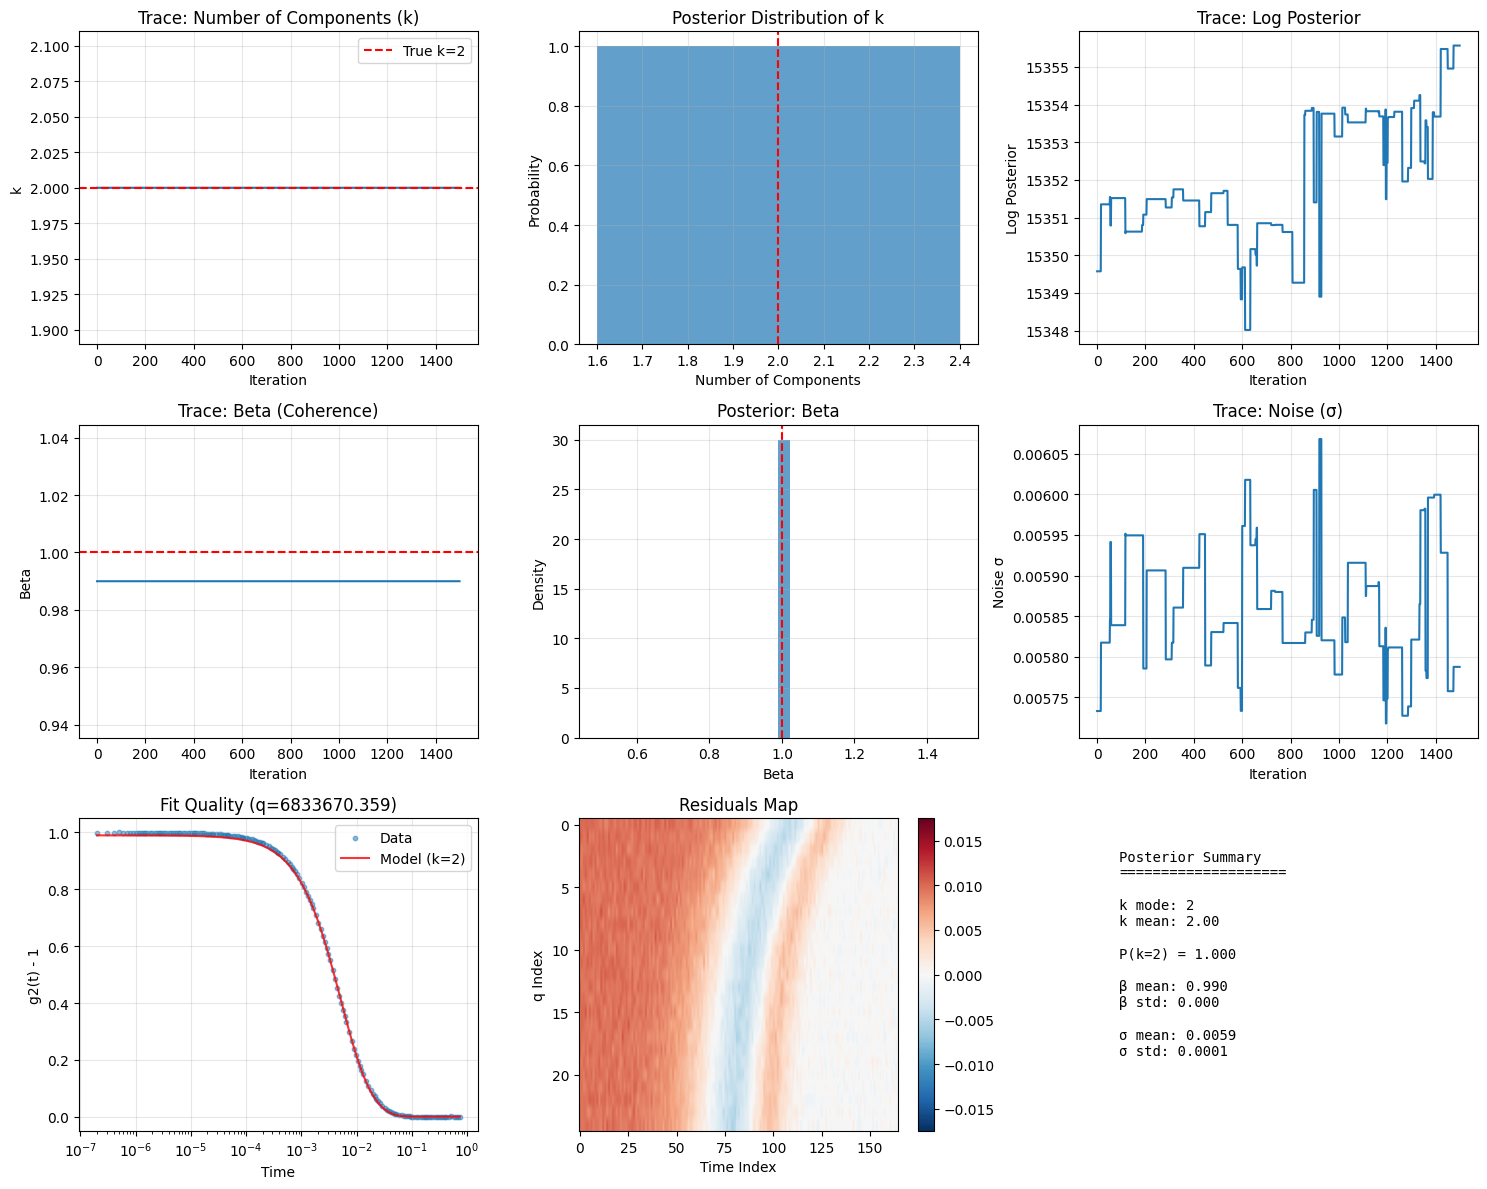


POSTERIOR SUMMARY

Posterior probabilities for k:
  P(k=2 | data) = 1.0000 *

Beta posterior: 0.990 ± 0.000
True beta: 1.000

Noise posterior: 0.0059 ± 0.0001
True noise: 0.0005


In [10]:
if __name__ == "__main__":
    # Setup
    key = random.PRNGKey(1339)
    

## generate data 
    key, model_key, data_key = jax.random.split(key, 3)

    q_vals, t_vals, _ = prep_data_g2("~/repos/DLS/Experimental_data_083122/stock_100nm.csv")
    # True parameters for generating synthetic data
    true_params = {
        'k': 2,
        'beta': 1.0,
        'amp': jnp.array([0.5, 0.5]),
        'mu': jnp.array([1.4, 0.3]),
        'sig': jnp.array([0.2, 0.09]),
        'sigma': 0.0005
        # 'sigma': 0.0
    }
    true_g2 = g2_minus1_matrix(
        q_vals, t_vals,
        true_params['amp'], true_params['mu'], true_params['sig'], true_params['beta']
    )

    true_k = 2
    data = true_g2 + true_params['sigma'] * jax.random.normal(data_key, shape=true_g2.shape)

    
    print(f"Data shape: {data.shape}")
    print(f"True parameters: k={true_params['k']}, beta={true_params['beta']:.3f}")
    print(f"True mu: {true_params['mu']}")
    print(f"True sig: {true_params['sig']}")
    
    # Set priors
    k_max = 5
    prior_params = {
        'amp_alpha': 1.0,           # Dirichlet concentration
        'log_mu_mean': jnp.log(0.5),  # Log-normal prior for mu
        'log_mu_std': 0.5,
        'sig_alpha': 2.0,           # Beta parameters for sig
        'sig_beta': 2.0,
        'beta_alpha': 5.0,          # Beta prior for coherence factor
        'beta_beta': 2.0,           # Favors higher beta values
        'noise_a': 2.0,             # Inverse gamma for noise
        'noise_b': 0.0001,
    }
    
    # Initialize
    initial_k = 1
    initial_amp = jnp.zeros(k_max).at[:initial_k].set(1.0)
    initial_mu = jnp.zeros(k_max).at[:initial_k].set(0.7)
    initial_sig = jnp.zeros(k_max).at[:initial_k].set(0.09)
    initial_beta = 0.7
    initial_sigma = 0.01
    
    initial_state = DLSState(
        k=initial_k,
        amp=initial_amp,
        mu=initial_mu,
        sig=initial_sig,
        beta=initial_beta,
        sigma_noise=initial_sigma,
        log_posterior=0.0
    )
    
    # Run RJMCMC
    n_iter = 20_000
    burn_in = 18_500
    
    print(f"\nRunning RJMCMC for {n_iter} iterations...")
    key, sampler_key = random.split(key)
    # samples = rjmcmc_sampler_dls(
    samples = rjmcmc_sampler_dls_paper(
        key=sampler_key,
        n_iter=n_iter,
        initial_state=initial_state,
        data=data,
        q_values=q_vals,
        t_values=t_vals,
        k_max=k_max,
        prior_params=prior_params,
        verbose=True
    )
    
    # Plot results
    fig = plot_dls_results(samples, data, q_vals, t_vals, burn_in=burn_in, true_params=true_params)
    plt.show()
    
    # Print summary
    k_samples = samples['k'][burn_in:]
    unique_k, counts = jnp.unique(k_samples, return_counts=True)
    posterior_probs = counts / len(k_samples)
    
    print("\n" + "="*50)
    print("POSTERIOR SUMMARY")
    print("="*50)
    print(f"\nPosterior probabilities for k:")
    for k_val, prob in sorted(zip(unique_k, posterior_probs), key=lambda x: -x[1]):
        stars = "*" if k_val == true_params['k'] else " "
        print(f"  P(k={k_val} | data) = {prob:.4f} {stars}")
    
    print(f"\nBeta posterior: {jnp.mean(samples['beta'][burn_in:]):.3f} ± {jnp.std(samples['beta'][burn_in:]):.3f}")
    print(f"True beta: {true_params['beta']:.3f}")
    
    print(f"\nNoise posterior: {jnp.mean(samples['sigma_noise'][burn_in:]):.4f} ± {jnp.std(samples['sigma_noise'][burn_in:]):.4f}")
    print(f"True noise: {true_params['sigma']:.4f}")


In [7]:
# diffusion_coef(true_params['mu']*SCALING_CONST)
# posterior_probs
print(f"True parameters: k={true_params['k']}, beta={true_params['beta']:.3f}")
print(f"True amp: {true_params['amp']}")
print(f"True mu: {true_params['mu']}")
print(f"True sig: {true_params['sig']}")
print(f"True noise: {true_params['sigma']}")
print("==============================================")

final_state = samples["state_snapshots"][-1]
# final_state.amp, final_state.mu, final_state.sig, final_state.beta, final_state.sigma_noise
print(f"Final state parameters: k={final_state.k}, beta={final_state.beta:.3f}")
print(f"Final state amp: {final_state.amp}")
print(f"Final state mu: {final_state.mu}")
print(f"Final state sig: {final_state.sig}")
print(f"Final state noise: {final_state.sigma_noise}")



True parameters: k=2, beta=1.000
True amp: [0.5 0.5]
True mu: [1.4 0.3]
True sig: [0.2  0.09]
True noise: 0.0005
Final state parameters: k=2, beta=0.990
Final state amp: [0.27281024 0.72718976 0.         0.         0.        ]
Final state mu: [0.200804   0.98845097 0.         0.         0.        ]
Final state sig: [0.06662513 0.14804246 0.         0.         0.        ]
Final state noise: 0.007308216884108881


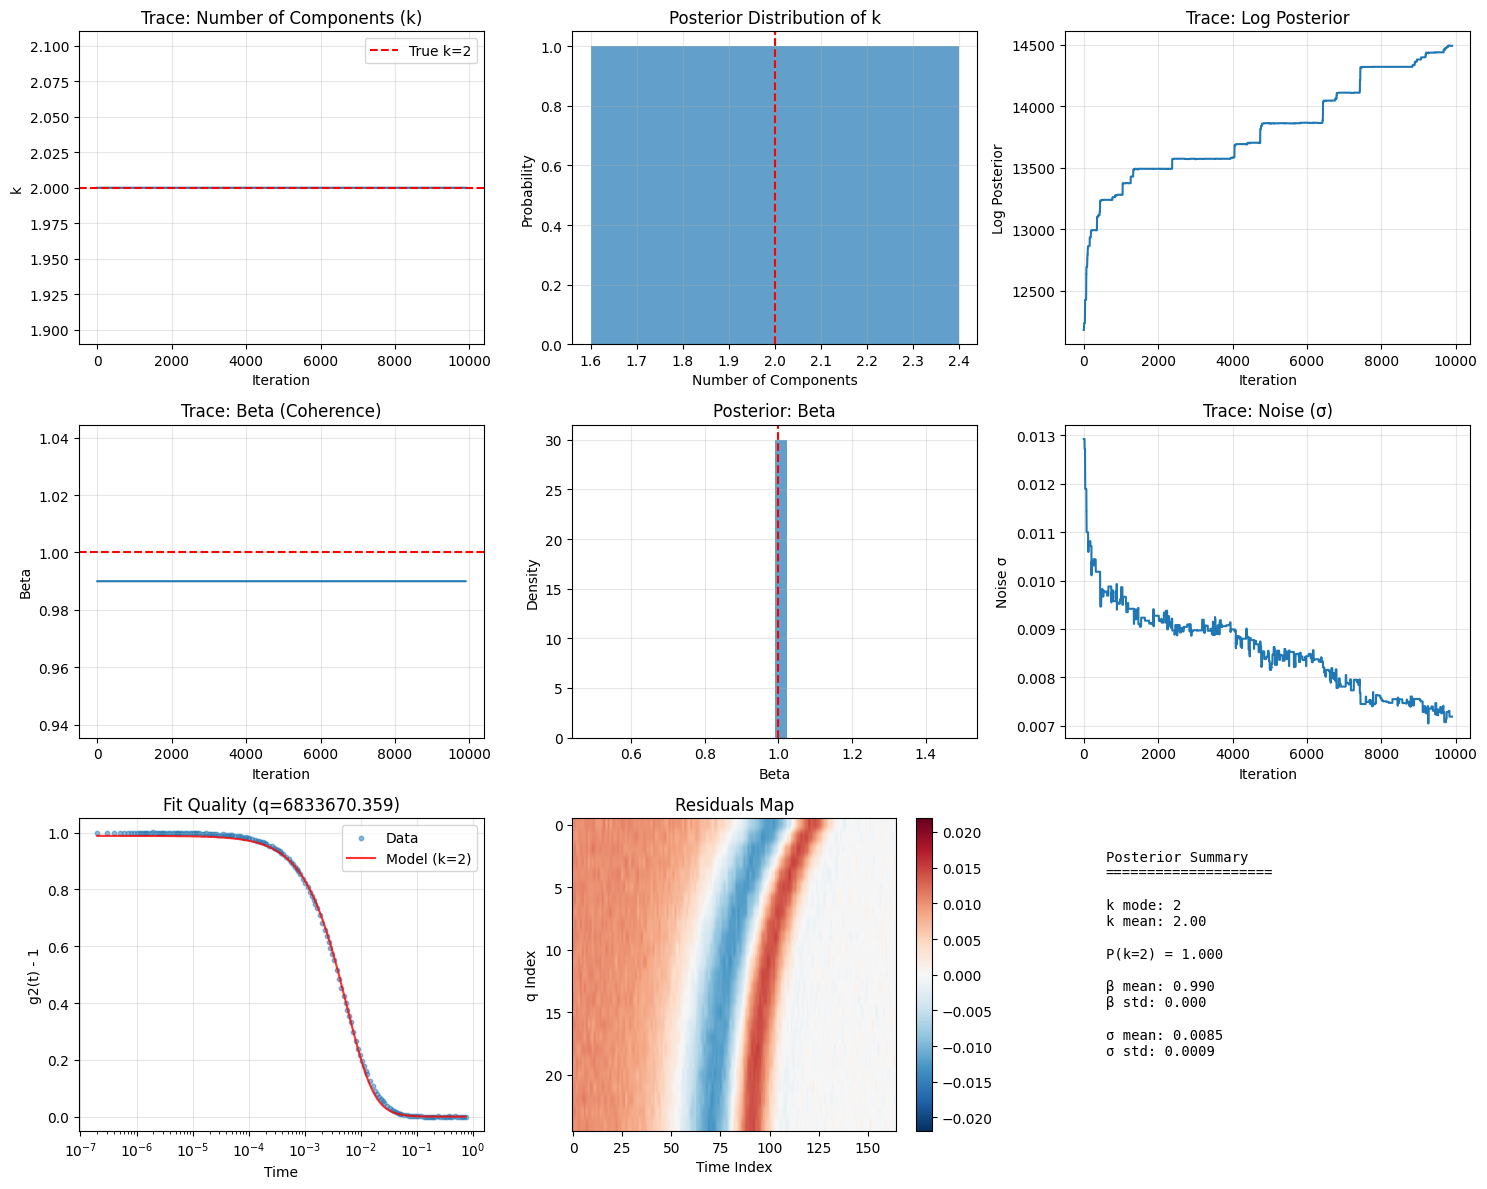

In [8]:
fig = plot_dls_results(samples, data, q_vals, t_vals, burn_in=100, true_params=true_params)
